МИНИМАЛЬНОЕ ЧИСЛО КУРЬЕРОВ: ИССЛЕДОВАНИЕ

1. Проверка на примере из условия:
   Заказов: 4, нужно курьеров: 3 (ожидается 3)
   Заказ 1: 08:00:00–11:00:00 → курьер 1
   Заказ 2: 09:00:00–10:00:00 → курьер 2
   Заказ 3: 10:00:00–11:10:00 → курьер 2
   Заказ 4: 10:59:59–13:00:00 → курьер 3

2. Рисуем графики:
   Маленький набор (4 заказа) — диаграмма Ганта...


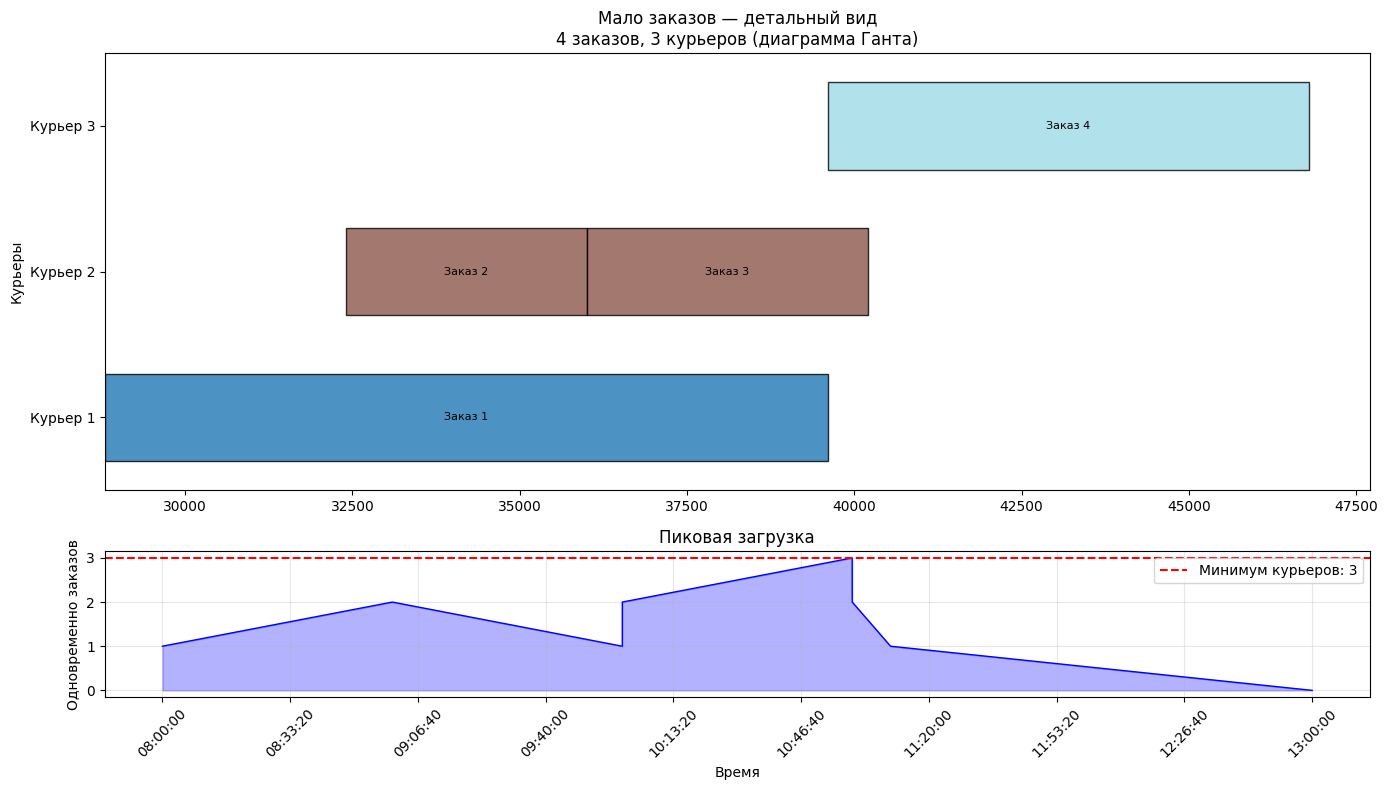

График сохранён в schedule.png
Нужно минимум 3 курьеров
   Большой набор (~1000 заказов) — тепловая карта...
   Сгенерировано 123 заказов
   Нужно курьеров: 11


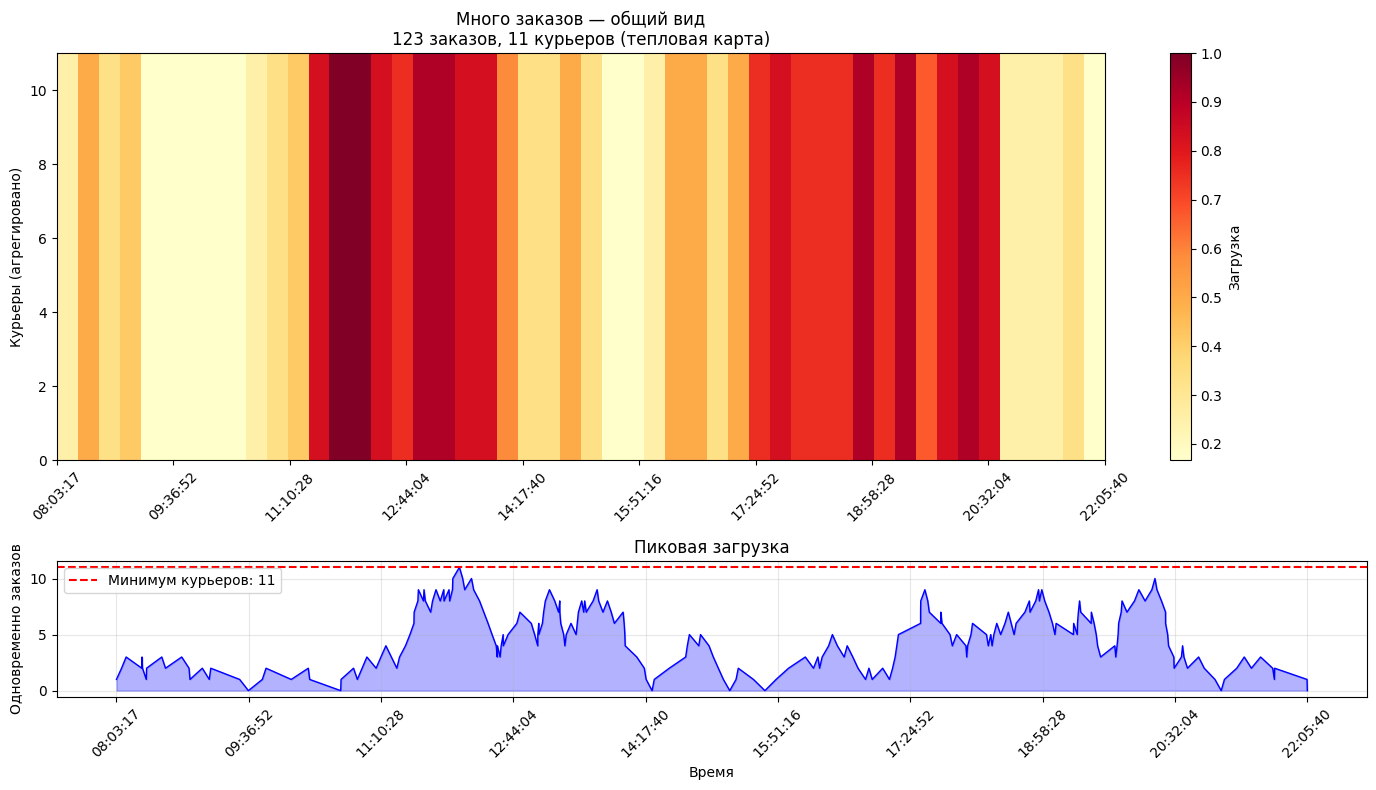

График сохранён в schedule.png
Нужно минимум 11 курьеров

3. Динамика: добавляем и удаляем заказы на лету
   3 заказа → нужно 2 курьера
   + ещё один → нужно 3 курьера
   удалили последний → снова 2 курьера

4. Зависимость от спроса:
   Интенсивность 2 зак/час → 33 заказов, нужно 3 курьеров
   Интенсивность 5 зак/час → 85 заказов, нужно 8 курьеров
   Интенсивность 10 зак/час → 199 заказов, нужно 13 курьеров
   Интенсивность 15 зак/час → 303 заказов, нужно 20 курьеров
   Интенсивность 20 зак/час → 408 заказов, нужно 27 курьеров


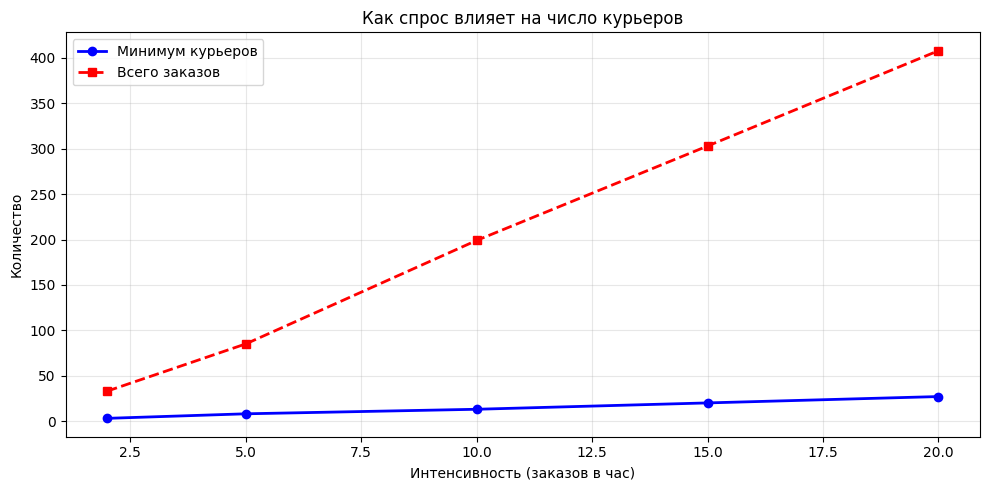


5. Зависимость от радиуса города:
   Радиус 5 км: среднее время доставки 15 мин, нужно 7 курьеров
   Радиус 10 км: среднее время доставки 21 мин, нужно 8 курьеров
   Радиус 15 км: среднее время доставки 26 мин, нужно 10 курьеров
   Радиус 20 км: среднее время доставки 31 мин, нужно 11 курьеров
   Радиус 30 км: среднее время доставки 42 мин, нужно 13 курьеров


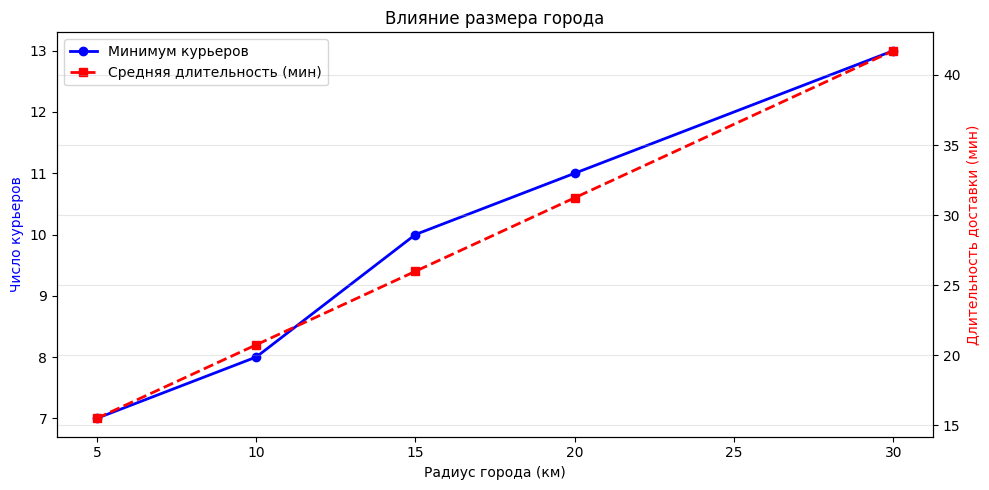


Готово! Сохранены файлы:
  schedule.png — визуализация расписания
  demand_vs_couriers.png — влияние спроса
  radius_vs_couriers.png — влияние размера города


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import heapq
import random


# Перевод времени из строки в секунды
def to_seconds(t):
    h, m, s = map(int, t.split(':'))
    return h * 3600 + m * 60 + s


# Обратный перевод
def from_seconds(sec):
    h = sec // 3600
    m = (sec % 3600) // 60
    s = sec % 60
    return f"{h:02d}:{m:02d}:{s:02d}"


# Основной алгоритм: считает минимальное число курьеров и кто какой заказ везёт
def count_couriers(orders):
    # orders — список пар (start, finish) в секундах
    
    # Запоминаем исходные позиции, чтобы потом вернуть распределение
    indexed = [(s, f, i) for i, (s, f) in enumerate(orders)]
    indexed.sort(key=lambda x: x[0])  # сортируем по времени старта
    
    heap = []          # куча: (время освобождения, id курьера)
    who = [-1] * len(orders)  # какой курьер взял заказ
    courier_cnt = 0
    
    for start, finish, idx in indexed:
        if heap and heap[0][0] <= start:
            # Какой-то курьер уже свободен — даём заказ ему
            free_time, courier_id = heapq.heapreplace(heap, (finish, heap[0][1]))
            who[idx] = courier_id
        else:
            # Все заняты — нанимаем нового
            who[idx] = courier_cnt
            heapq.heappush(heap, (finish, courier_cnt))
            courier_cnt += 1
            
    return courier_cnt, who


# Рисуем картинку с расписанием
def draw_schedule(orders, title="Расписание"):
    n = len(orders)
    total_couriers, assignment = count_couriers(orders)
    
    fig, (ax_gantt, ax_stats) = plt.subplots(2, 1, figsize=(14, 8),
                                              gridspec_kw={'height_ratios': [3, 1]})
    
    # Границы времени
    all_times = []
    for s, f in orders:
        all_times.extend([s, f])
    t_min = min(all_times)
    t_max = max(all_times)
    
    # ---- Верхний график: Гант или тепловая карта ----
    if n <= 20:
        # Рисуем классическую диаграмму Ганта
        colors = plt.cm.tab20(np.linspace(0, 1, max(total_couriers, 1)))
        
        ax_gantt.set_yticks(range(total_couriers))
        ax_gantt.set_yticklabels([f"Курьер {i+1}" for i in range(total_couriers)])
        
        for i, (start, finish) in enumerate(orders):
            cid = assignment[i]
            ax_gantt.barh(cid, finish - start, left=start, height=0.6,
                         color=colors[cid], edgecolor='black', alpha=0.8)
            mid = start + (finish - start) / 2
            ax_gantt.text(mid, cid, f"Заказ {i+1}", ha='center', va='center', fontsize=8)
        
        ax_gantt.set_ylim(-0.5, total_couriers - 0.5)
        ax_gantt.set_ylabel("Курьеры")
        ax_gantt.set_title(f"{title}\n{n} заказов, {total_couriers} курьеров (диаграмма Ганта)")
    else:
        # Заказов много — показываем тепловую карту загрузки
        bins = 50
        load = np.zeros((total_couriers, bins))
        step = (t_max - t_min) / bins
        
        for start, finish in orders:
            a = min(int((start - t_min) / step), bins - 1)
            b = min(int((finish - t_min) / step), bins - 1)
            for col in range(a, b + 1):
                load[:, col] += 1
        
        load = load / max(1, load.max())
        
        im = ax_gantt.imshow(load, aspect='auto', cmap='YlOrRd',
                            extent=[t_min, t_max, 0, total_couriers])
        ax_gantt.set_ylabel("Курьеры (агрегировано)")
        ax_gantt.set_title(f"{title}\n{n} заказов, {total_couriers} курьеров (тепловая карта)")
        plt.colorbar(im, ax=ax_gantt, label='Загрузка')
        
        ticks = np.linspace(t_min, t_max, 10)
        ax_gantt.set_xticks(ticks)
        ax_gantt.set_xticklabels([from_seconds(int(t)) for t in ticks], rotation=45)
    
    # ---- Нижний график: сколько заказов одновременно ----
    events = []
    for s, f in orders:
        events.append((s, 1))
        events.append((f, -1))
    events.sort()
    
    timeline = []
    load_values = []
    cur = 0
    for t, delta in events:
        cur += delta
        timeline.append(t)
        load_values.append(cur)
    
    ax_stats.fill_between(timeline, load_values, alpha=0.3, color='blue')
    ax_stats.plot(timeline, load_values, 'b-', linewidth=1)
    ax_stats.axhline(y=total_couriers, color='r', linestyle='--',
                    label=f'Минимум курьеров: {total_couriers}')
    ax_stats.set_xlabel("Время")
    ax_stats.set_ylabel("Одновременно заказов")
    ax_stats.set_title("Пиковая загрузка")
    ax_stats.legend()
    ax_stats.grid(True, alpha=0.3)
    
    ticks = np.linspace(t_min, t_max, 10)
    ax_stats.set_xticks(ticks)
    ax_stats.set_xticklabels([from_seconds(int(t)) for t in ticks], rotation=45)
    
    plt.tight_layout()
    plt.savefig('schedule.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f"График сохранён в schedule.png")
    print(f"Нужно минимум {total_couriers} курьеров")
    
    return total_couriers, assignment


# Класс для динамического добавления/удаления заказов
class OrderTracker:
    def __init__(self):
        self.orders = []
    
    def add(self, start, finish):
        self.orders.append((start, finish))
    
    def remove(self, start, finish):
        try:
            self.orders.remove((start, finish))
        except ValueError:
            for i, (s, f) in enumerate(self.orders):
                if s == start and f == finish:
                    self.orders.pop(i)
                    break
    
    def min_couriers(self):
        if not self.orders:
            return 0
        cnt, _ = count_couriers(self.orders)
        return cnt


# Модель спроса: генерирует заказы с учётом часов пик и размера города
class CityDemand:
    def __init__(self, radius=10, peak_hours=None, base_rate=5, peak_mult=3, seed=42):
        self.radius = radius
        self.peak_hours = peak_hours or [(11, 14), (17, 20)]
        self.base_rate = base_rate
        self.peak_mult = peak_mult
        random.seed(seed)
        np.random.seed(seed)
    
    def rate_at(self, hour):
        for start, end in self.peak_hours:
            if start <= hour < end:
                return self.base_rate * self.peak_mult
        return self.base_rate
    
    def generate(self, from_hour=8, to_hour=22):
        orders = []
        for hour in range(from_hour, to_hour):
            rate = self.rate_at(hour)
            n = np.random.poisson(rate)

            for _ in range(n):
                minute = random.randint(0, 59)
                sec = random.randint(0, 59)
                start = hour * 3600 + minute * 60 + sec
                
                # Расстояние по распределению Релея (городская модель)
                dist = np.random.rayleigh(scale=self.radius / 3)
                # В пробках едем медленнее
                speed = 20 if self.rate_at(hour) > self.base_rate else 30
                travel = int(dist / speed * 3600)
                
                # Время на входе/выходе
                handling = random.randint(300, 900)
                duration = travel + handling
                
                finish = start + duration
                if finish < 23 * 3600:
                    orders.append((start, finish))
        
        orders.sort(key=lambda x: x[0])
        return orders


# Запуск всего исследования
def main():
    print("=" * 60)
    print("МИНИМАЛЬНОЕ ЧИСЛО КУРЬЕРОВ: ИССЛЕДОВАНИЕ")
    print("=" * 60)
    
    # 1. Тестовый пример из условия
    print("\n1. Проверка на примере из условия:")
    sample = [
        (to_seconds("08:00:00"), to_seconds("11:00:00")),
        (to_seconds("09:00:00"), to_seconds("10:00:00")),
        (to_seconds("10:00:00"), to_seconds("11:10:00")),
        (to_seconds("10:59:59"), to_seconds("13:00:00")),
    ]
    n, assign = count_couriers(sample)
    print(f"   Заказов: 4, нужно курьеров: {n} (ожидается 3)")
    for i, (s, f) in enumerate(sample):
        print(f"   Заказ {i+1}: {from_seconds(s)}–{from_seconds(f)} → курьер {assign[i]+1}")
    
    # 2. Визуализация
    print("\n2. Рисуем графики:")
    
    print("   Маленький набор (4 заказа) — диаграмма Ганта...")
    draw_schedule(sample, "Мало заказов — детальный вид")
    
    print("   Большой набор (~1000 заказов) — тепловая карта...")
    city = CityDemand(radius=15, seed=123)
    big = city.generate(8, 22)
    print(f"   Сгенерировано {len(big)} заказов")
    n_big, _ = count_couriers(big)
    print(f"   Нужно курьеров: {n_big}")
    draw_schedule(big[:200], "Много заказов — общий вид")
    
    # 3. Динамическое добавление и удаление
    print("\n3. Динамика: добавляем и удаляем заказы на лету")
    tracker = OrderTracker()
    tracker.add(to_seconds("08:00:00"), to_seconds("10:00:00"))
    tracker.add(to_seconds("09:00:00"), to_seconds("11:00:00"))
    tracker.add(to_seconds("10:00:00"), to_seconds("12:00:00"))
    print(f"   3 заказа → нужно {tracker.min_couriers()} курьера")
    
    tracker.add(to_seconds("08:30:00"), to_seconds("09:30:00"))
    print(f"   + ещё один → нужно {tracker.min_couriers()} курьера")
    
    tracker.remove(to_seconds("08:30:00"), to_seconds("09:30:00"))
    print(f"   удалили последний → снова {tracker.min_couriers()} курьера")
    
    # 4. Как зависит число курьеров от интенсивности заказов
    print("\n4. Зависимость от спроса:")
    
    points = []
    for rate in [2, 5, 10, 15, 20]:
        m = CityDemand(base_rate=rate, peak_mult=2, seed=42)
        orders = m.generate(8, 22)
        need, _ = count_couriers(orders)
        points.append((rate, need, len(orders)))
        print(f"   Интенсивность {rate} зак/час → {len(orders)} заказов, нужно {need} курьеров")
    
    rates, couriers, totals = zip(*points)
    plt.figure(figsize=(10, 5))
    plt.plot(rates, couriers, 'b-o', label='Минимум курьеров', linewidth=2)
    plt.plot(rates, totals, 'r--s', label='Всего заказов', linewidth=2)
    plt.xlabel('Интенсивность (заказов в час)')
    plt.ylabel('Количество')
    plt.title('Как спрос влияет на число курьеров')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig('demand_vs_couriers.png', dpi=150)
    plt.show()
    
    # 5. Как влияет размер города
    print("\n5. Зависимость от радиуса города:")
    
    pts = []
    for r in [5, 10, 15, 20, 30]:
        m = CityDemand(radius=r, base_rate=5, peak_mult=2, seed=42)
        orders = m.generate(8, 22)
        need, _ = count_couriers(orders)
        avg_dur = np.mean([f - s for s, f in orders]) / 60
        pts.append((r, need, avg_dur))
        print(f"   Радиус {r} км: среднее время доставки {avg_dur:.0f} мин, нужно {need} курьеров")
    
    radii, couriers, durs = zip(*pts)
    
    fig, ax1 = plt.subplots(figsize=(10, 5))
    ax2 = ax1.twinx()
    ax1.plot(radii, couriers, 'b-o', label='Минимум курьеров', linewidth=2)
    ax2.plot(radii, durs, 'r--s', label='Средняя длительность (мин)', linewidth=2)
    ax1.set_xlabel('Радиус города (км)')
    ax1.set_ylabel('Число курьеров', color='b')
    ax2.set_ylabel('Длительность доставки (мин)', color='r')
    plt.title('Влияние размера города')
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig('radius_vs_couriers.png', dpi=150)
    plt.show()
    
    print("\n" + "=" * 60)
    print("Готово! Сохранены файлы:")
    print("  schedule.png — визуализация расписания")
    print("  demand_vs_couriers.png — влияние спроса")
    print("  radius_vs_couriers.png — влияние размера города")
    print("=" * 60)


if __name__ == "__main__":
    main()